In [10]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('insurance.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [11]:
df.info()
df.shape
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 57.6+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [12]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(1)

In [14]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

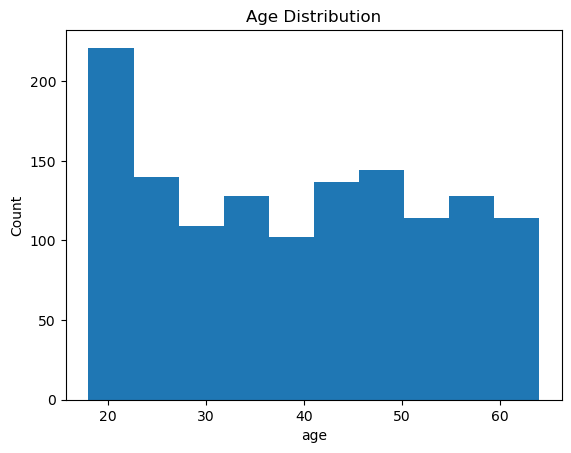

In [15]:
plt.hist(df['age'], bins= 10)
plt.title("Age Distribution")
plt.xlabel("age")
plt.ylabel("Count")
plt.show()

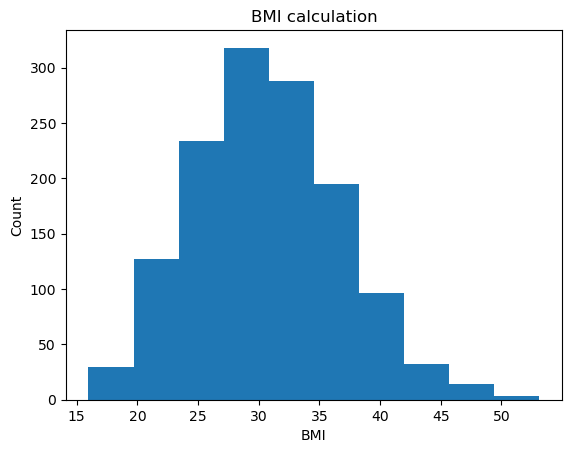

In [16]:
plt.hist(df['bmi'], bins= 10)
plt.title("BMI calculation")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.show()

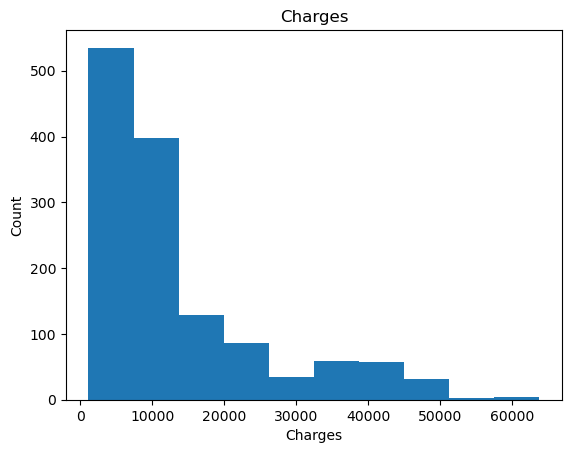

In [17]:
plt.hist(df['charges'], bins= 10)
plt.title("Charges")
plt.xlabel("Charges")
plt.ylabel("Count")
plt.show()

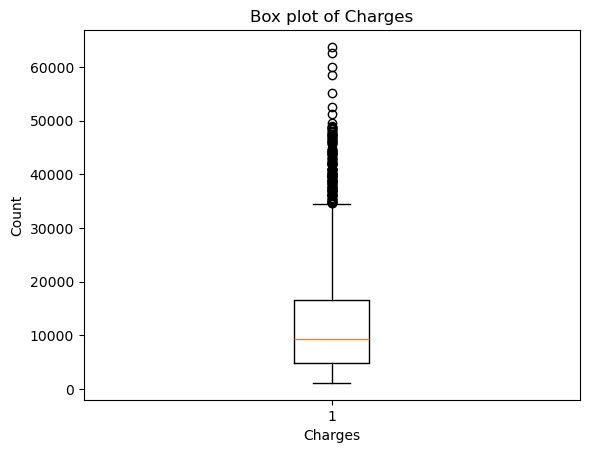

In [18]:
plt.boxplot(df['charges'])
plt.title("Box plot of Charges")
plt.xlabel("Charges")
plt.ylabel("Count")
plt.show()

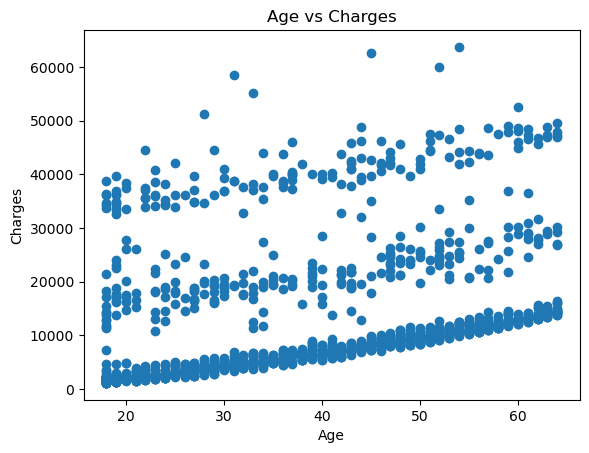

In [19]:
plt.scatter(df['age'], df['charges'])
plt.title("Age vs Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

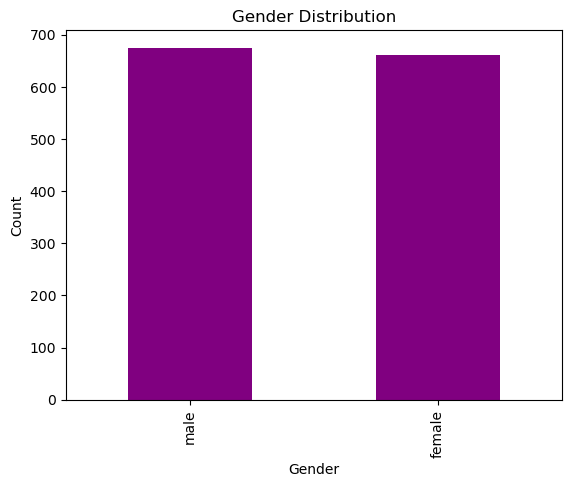

In [20]:
df['sex'].value_counts().plot(kind='bar', color ='purple')
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

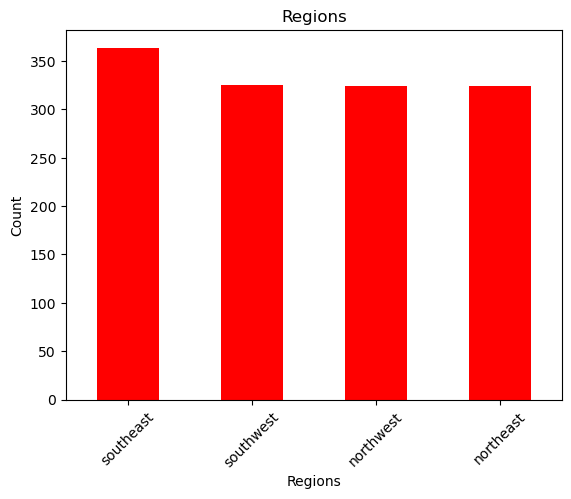

In [21]:
df['region'].value_counts().plot(kind='bar', color='red')
plt.title("Regions")
plt.xlabel("Regions")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

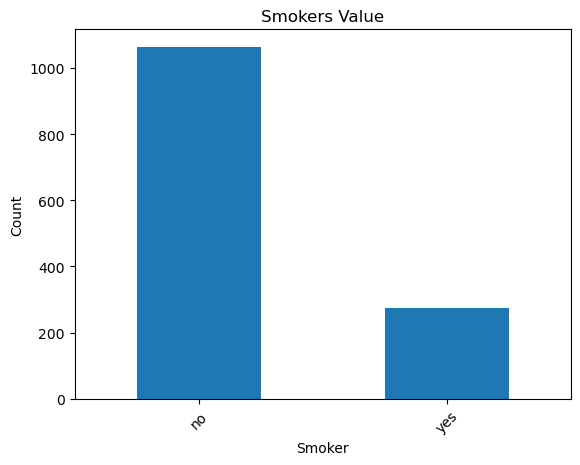

In [22]:
df['smoker'].value_counts().plot(kind='bar')
plt.title("Smokers Value")
plt.xlabel("Smoker")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

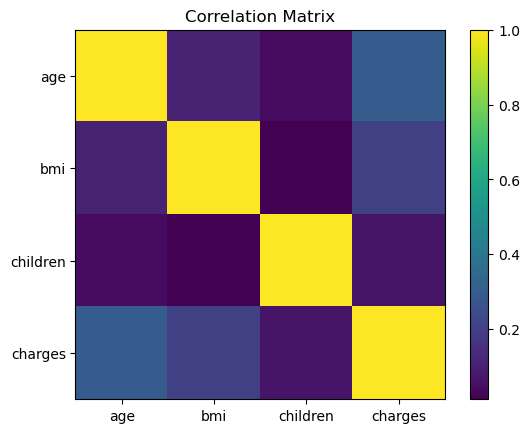

In [26]:
# correlation Heatmap
plt.figure()
corr = df.corr(numeric_only=True)
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)),corr.columns)
plt.yticks(range(len(corr.columns)),corr.columns)
plt.title("Correlation Matrix")
plt.show()

In [27]:
%pip install scikit-learn

In [29]:
import sklearn
print("Scikit-learn version:", sklearn.__version__)

Scikit-learn version: 1.7.0


In [33]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso 
# ridge, lasso are types of LR
# Ridge is to avoid overfitting, unddrfit
# Lasso is for feature selection
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

In [34]:
df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109344,0.041536,0.298308
bmi,0.109344,1.000000,0.012755,0.198401
children,0.041536,0.012755,1.000000,0.067389
charges,0.298308,0.198401,0.067389,1.000000


In [35]:
# Sort with absolute value for above correlations
abs(df.corr(numeric_only=True))['charges'].sort_values(ascending=False)

charges     1.000000
age         0.298308
bmi         0.198401
children    0.067389
Name: charges, dtype: float64